In [1]:
"""
=============================================================================
SAM PAPER DETECTION PIPELINE - PRODUCTION VERSION
=============================================================================
Complete pipeline with:
- Perspective correction (unwarp angled photos)
- Orientation normalization (force landscape)
- Heavy crayon texture (matches dataset)
- Pure white background
- Direct resize to 512×362

INSTALLATION:
    uv pip install segment-anything

=============================================================================
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor
import urllib.request
from pathlib import Path
from typing import List, Dict, Tuple, Optional
from scipy.ndimage import gaussian_filter

In [2]:
# =============================================================================
# GEOMETRIC FILTERING FUNCTIONS
# =============================================================================

def is_paper_like(mask: np.ndarray, img_shape: Tuple[int, int],
                  min_area_ratio: float = 0.05,
                  max_area_ratio: float = 0.85,
                  min_aspect_ratio: float = 0.5,
                  max_aspect_ratio: float = 2.5,
                  min_rectangularity: float = 0.7) -> Tuple[bool, Dict]:
    """Check if a mask represents a paper-like object"""
    img_area = img_shape[0] * img_shape[1]

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return False, {"reason": "no_contours"}

    contour = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(contour)

    area_ratio = area / img_area
    if area_ratio < min_area_ratio:
        return False, {"reason": "too_small", "area_ratio": area_ratio}
    if area_ratio > max_area_ratio:
        return False, {"reason": "too_large_likely_background", "area_ratio": area_ratio}

    rect = cv2.minAreaRect(contour)
    width, height = rect[1]

    if width == 0 or height == 0:
        return False, {"reason": "degenerate_shape"}

    aspect_ratio = max(width, height) / min(width, height)
    if aspect_ratio < min_aspect_ratio or aspect_ratio > max_aspect_ratio:
        return False, {"reason": "bad_aspect_ratio", "aspect_ratio": aspect_ratio}

    bbox_area = width * height
    rectangularity = area / bbox_area if bbox_area > 0 else 0
    if rectangularity < min_rectangularity:
        return False, {"reason": "not_rectangular", "rectangularity": rectangularity}

    epsilon = 0.02 * cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, epsilon, True)
    num_corners = len(approx)
    if num_corners < 4 or num_corners > 8:
        return False, {"reason": "wrong_corner_count", "num_corners": num_corners}

    hull = cv2.convexHull(contour)
    hull_area = cv2.contourArea(hull)
    solidity = area / hull_area if hull_area > 0 else 0
    if solidity < 0.8:
        return False, {"reason": "not_convex", "solidity": solidity}

    metrics = {
        "reason": "PAPER_DETECTED",
        "area_ratio": area_ratio,
        "aspect_ratio": aspect_ratio,
        "rectangularity": rectangularity,
        "num_corners": num_corners,
        "solidity": solidity,
        "area_pixels": int(area),
        "score": (rectangularity + solidity) / 2
    }

    return True, metrics

In [3]:
def find_best_paper_mask(all_masks: List[Dict], img_shape: Tuple[int, int],
                         verbose: bool = True) -> Tuple[Optional[np.ndarray], Dict]:
    """Find the best paper candidate from all SAM masks"""
    if verbose:
        print(f"\n Analyzing {len(all_masks)} detected objects...")
        print(f"   Image size: {img_shape[1]}×{img_shape[0]} pixels")

    paper_candidates = []

    for i, mask_dict in enumerate(all_masks):
        mask = (mask_dict['segmentation'].astype(np.uint8)) * 255
        is_paper, metrics = is_paper_like(mask, img_shape)

        if is_paper:
            paper_candidates.append({
                'index': i,
                'mask': mask,
                'metrics': metrics,
                'sam_area': mask_dict['area']
            })

            if verbose:
                print(f"   ✓ Object {i+1}: PAPER CANDIDATE")
                print(f"      Score: {metrics['score']:.3f} | Area: {metrics['area_ratio']:.1%} | Corners: {metrics['num_corners']}")
        else:
            if verbose:
                reason = metrics.get('reason', 'unknown')
                print(f"   ✗ Object {i+1}: Rejected - {reason}")

    if not paper_candidates:
        if verbose:
            print("\n No paper-like objects found!")
        return None, {}

    paper_candidates.sort(key=lambda x: x['metrics']['score'], reverse=True)
    best = paper_candidates[0]

    if verbose:
        print(f"\n Selected best paper: Object {best['index']+1} (score: {best['metrics']['score']:.3f})")

    return best['mask'], best['metrics']

In [4]:
# =============================================================================
# PERSPECTIVE CORRECTION FUNCTIONS
# =============================================================================

def order_corners(corners: np.ndarray) -> np.ndarray:
    """Order corners as: [top-left, top-right, bottom-right, bottom-left]"""
    corners = corners.reshape(4, 2)
    ordered = np.zeros((4, 2), dtype=np.float32)

    s = corners.sum(axis=1)
    ordered[0] = corners[np.argmin(s)]  # top-left
    ordered[2] = corners[np.argmax(s)]  # bottom-right

    diff = np.diff(corners, axis=1)
    ordered[1] = corners[np.argmin(diff)]  # top-right
    ordered[3] = corners[np.argmax(diff)]  # bottom-left

    return ordered

In [5]:
def find_paper_corners(mask: np.ndarray) -> Optional[np.ndarray]:
    """Find the 4 corners of the paper from the mask"""
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    paper_contour = max(contours, key=cv2.contourArea)

    epsilon = 0.02 * cv2.arcLength(paper_contour, True)
    approx = cv2.approxPolyDP(paper_contour, epsilon, True)

    if len(approx) == 4:
        corners = approx.reshape(4, 2)
    elif len(approx) > 4:
        hull = cv2.convexHull(paper_contour)
        hull_points = hull.reshape(-1, 2)

        top_left = hull_points[np.argmin(hull_points.sum(axis=1))]
        bottom_right = hull_points[np.argmax(hull_points.sum(axis=1))]
        top_right = hull_points[np.argmin(hull_points[:, 0] - hull_points[:, 1])]
        bottom_left = hull_points[np.argmax(hull_points[:, 0] - hull_points[:, 1])]

        corners = np.array([top_left, top_right, bottom_right, bottom_left])
    else:
        x, y, w, h = cv2.boundingRect(paper_contour)
        corners = np.array([
            [x, y], [x + w, y], [x + w, y + h], [x, y + h]
        ])

    return corners

In [6]:
def correct_perspective(img: np.ndarray, corners: np.ndarray) -> np.ndarray:
    """
    Apply perspective transformation to unwarp the paper
    Preserves the natural aspect ratio of the paper (doesn't force dimensions)
    """
    corners = order_corners(corners)

    # Calculate the actual width and height of the paper
    # Use maximum of top/bottom widths and left/right heights
    width_top = np.linalg.norm(corners[1] - corners[0])
    width_bottom = np.linalg.norm(corners[2] - corners[3])
    width = max(width_top, width_bottom)

    height_left = np.linalg.norm(corners[3] - corners[0])
    height_right = np.linalg.norm(corners[2] - corners[1])
    height = max(height_left, height_right)

    # Define destination corners (perfect rectangle with natural dimensions)
    dst_corners = np.array([
        [0, 0],
        [width - 1, 0],
        [width - 1, height - 1],
        [0, height - 1]
    ], dtype=np.float32)

    # Calculate perspective transformation matrix
    M = cv2.getPerspectiveTransform(corners.astype(np.float32), dst_corners)

    # Apply transformation
    corrected = cv2.warpPerspective(img, M, (int(width), int(height)))

    return corrected

In [7]:
# =============================================================================
# SAM PAPER DETECTOR CLASS
# =============================================================================

class SAM_PaperDetector:
    """SAM-based paper detector with geometric filtering"""

    def __init__(self, model_type="vit_b"):
        print(f"Initializing SAM model ({model_type})...")

        self.model_type = model_type
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"   Device: {self.device}")

        if self.device.type == 'cpu':
            print("   WARNING: Running on CPU - this will be SLOW!")
            print("   Recommendation: Enable GPU for 20-30x speed improvement")

        checkpoint_path = self._download_checkpoint(model_type)

        print("Loading SAM model...")
        self.sam = sam_model_registry[model_type](checkpoint=checkpoint_path)
        self.sam.to(device=self.device)

        self.mask_generator = SamAutomaticMaskGenerator(
            model=self.sam,
            points_per_side=16,  # Optimized for speed
            pred_iou_thresh=0.90,
            stability_score_thresh=0.95,
            crop_n_layers=1,
            crop_n_points_downscale_factor=2,
            min_mask_region_area=1000,
        )

        print("✓ SAM model ready!")

    def _download_checkpoint(self, model_type):
        checkpoint_urls = {
            'vit_b': 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth',
            'vit_l': 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_l_0b3195.pth',
            'vit_h': 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth',
        }

        cache_dir = Path.home() / ".cache" / "sam_models"
        cache_dir.mkdir(parents=True, exist_ok=True)
        checkpoint_path = cache_dir / f"sam_{model_type}.pth"

        if not checkpoint_path.exists():
            print(f"Downloading SAM {model_type} checkpoint...")
            urllib.request.urlretrieve(
                checkpoint_urls[model_type],
                checkpoint_path,
                reporthook=self._download_progress
            )
            print(f"\n✓ Downloaded to {checkpoint_path}")
        else:
            print(f"✓ Using cached checkpoint: {checkpoint_path}")

        return str(checkpoint_path)

    def _download_progress(self, block_num, block_size, total_size):
        downloaded = block_num * block_size
        percent = min(downloaded / total_size * 100, 100)
        print(f"\r   Progress: {percent:.1f}%", end='', flush=True)

    def detect_paper_smart(self, img: np.ndarray, verbose: bool = True) -> Tuple[np.ndarray, List[Dict]]:
        """Detect paper using SAM + geometric filtering"""
        if verbose:
            print(" Running SAM automatic segmentation...")

        all_masks = self.mask_generator.generate(img)

        if len(all_masks) == 0:
            raise RuntimeError("No objects detected by SAM")

        if verbose:
            print(f"   Found {len(all_masks)} objects")

        best_mask, metrics = find_best_paper_mask(all_masks, img_shape=img.shape[:2], verbose=verbose)

        if best_mask is None:
            raise RuntimeError("No paper-like object detected")

        return best_mask, all_masks

In [8]:
# =============================================================================
# ORIENTATION NORMALIZATION
# =============================================================================

def normalize_orientation(img: np.ndarray) -> np.ndarray:
    """
    Force portrait → landscape orientation
    Dataset uses landscape (512×362), so all images must be landscape
    """
    h, w = img.shape[:2]

    if h > w:
        # Portrait - rotate 90° clockwise to landscape
        img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
        print(f"   ↻ Rotated portrait ({w}×{h}) → landscape ({h}×{w})")
    else:
        print(f"   → Already landscape ({w}×{h})")

    return img

In [9]:
# =============================================================================
# BACKGROUND PROCESSING FUNCTIONS
# =============================================================================

def apply_pure_white_background(img: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """Replace all non-paper pixels with PURE white (255, 255, 255)"""
    _, binary_mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    result = np.ones_like(img, dtype=np.uint8) * 255

    paper_pixels = binary_mask == 255
    result[paper_pixels] = img[paper_pixels]

    return result

In [10]:
def force_near_white_to_white(img: np.ndarray, threshold: int = 245) -> np.ndarray:
    """Force any near-white pixels to pure white - fixes interpolation artifacts"""
    near_white = np.all(img >= threshold, axis=2)
    img[near_white] = 255
    return img

In [11]:
def clean_white_background(img: np.ndarray) -> np.ndarray:
    """Make white areas pure white, preserve colored strokes"""
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)

    bright_mask = l_channel > 200
    l_channel[bright_mask] = 255

    lab_cleaned = cv2.merge((l_channel, a_channel, b_channel))
    result = cv2.cvtColor(lab_cleaned, cv2.COLOR_LAB2RGB)

    return result

In [12]:
def enhance_crayon_colors(img: np.ndarray) -> np.ndarray:
    """Boost saturation to make crayons vivid"""
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    h_channel, s_channel, v_channel = cv2.split(hsv)

    s_channel = s_channel.astype(np.float32)
    s_channel = s_channel * 1.15 + 5
    s_channel = np.clip(s_channel, 0, 255).astype(np.uint8)

    v_channel = v_channel.astype(np.float32)
    v_channel = v_channel * 1.02
    v_channel = np.clip(v_channel, 0, 255).astype(np.uint8)

    hsv_enhanced = cv2.merge((h_channel, s_channel, v_channel))
    result = cv2.cvtColor(hsv_enhanced, cv2.COLOR_HSV2RGB)

    return result

In [13]:
# =============================================================================
# HEAVY CRAYON TEXTURE (MANDATORY - MATCHES DATASET)
# =============================================================================

def add_heavy_crayon_texture(img: np.ndarray, grain_intensity: float = 0.5,
                            stroke_intensity: float = 0.4) -> np.ndarray:
    """
    Add heavy, visible crayon texture with directional strokes
    This is MANDATORY to match dataset appearance

    Features:
    - Heavy paper grain (obvious texture)
    - Directional stroke patterns
    - Slightly rough, not smooth
    - Visible uneven coverage

    Args:
        img: Input image
        grain_intensity: Paper grain strength (0.0-1.0)
        stroke_intensity: Stroke direction visibility (0.0-1.0)
    """
    h, w = img.shape[:2]
    result = img.astype(np.float32)

    # Find non-white pixels (where drawing exists)
    drawing_mask = np.any(img < 250, axis=2)

    # === 1. HEAVY PAPER GRAIN ===
    # Create coarse grain texture (more visible than subtle noise)
    grain = np.random.normal(0, 15, (h, w)).astype(np.float32)
    grain = cv2.GaussianBlur(grain, (3, 3), 0)

    # Apply grain to all channels
    for c in range(3):
        channel = result[:, :, c]
        channel[drawing_mask] += grain[drawing_mask] * grain_intensity
        result[:, :, c] = np.clip(channel, 0, 255)

    # === 2. DIRECTIONAL STROKE TEXTURE ===
    # Create random stroke directions (simulates crayon application)
    # Use Perlin-like noise for natural stroke patterns

    # Create directional noise at lower resolution
    low_h, low_w = h // 8, w // 8

    # Horizontal strokes (common in crayon coloring)
    h_strokes = np.random.randn(low_h, low_w) * 10
    h_strokes = cv2.resize(h_strokes, (w, h), interpolation=cv2.INTER_CUBIC)
    h_strokes = gaussian_filter(h_strokes, sigma=2)

    # Vertical strokes
    v_strokes = np.random.randn(low_h, low_w) * 10
    v_strokes = cv2.resize(v_strokes, (w, h), interpolation=cv2.INTER_CUBIC)
    v_strokes = gaussian_filter(v_strokes, sigma=2)

    # Combine stroke directions
    stroke_pattern = (h_strokes + v_strokes) * stroke_intensity

    # Apply strokes only to colored areas
    for c in range(3):
        channel = result[:, :, c]
        channel[drawing_mask] += stroke_pattern[drawing_mask]
        result[:, :, c] = np.clip(channel, 0, 255)

    # === 3. UNEVEN COVERAGE (Wax Buildup Effect) ===
    # Create patches of lighter/darker coverage
    coverage = np.random.random((h // 6, w // 6))
    coverage = cv2.resize(coverage, (w, h), interpolation=cv2.INTER_CUBIC)
    coverage = (coverage - 0.5) * 20 * grain_intensity  # -10 to +10 variation

    for c in range(3):
        channel = result[:, :, c]
        channel[drawing_mask] += coverage[drawing_mask]
        result[:, :, c] = np.clip(channel, 0, 255)

    # === 4. SLIGHT ROUGHNESS (High-Frequency Noise) ===
    # Add fine texture for "not smooth" appearance
    fine_noise = np.random.normal(0, 5, (h, w)).astype(np.float32)

    for c in range(3):
        channel = result[:, :, c]
        channel[drawing_mask] += fine_noise[drawing_mask] * 0.6
        result[:, :, c] = np.clip(channel, 0, 255)

    # === 5. EDGE SOFTENING (Crayon edges aren't perfectly sharp) ===
    # Very subtle blur only on drawing edges
    result_uint8 = result.astype(np.uint8)
    blurred = cv2.GaussianBlur(result_uint8, (3, 3), 0.5)

    # Only apply blur at edges of drawing
    edges = cv2.Canny(img, 50, 150)
    edges = cv2.dilate(edges, np.ones((3, 3), np.uint8), iterations=1)
    edge_mask = edges > 0

    result_uint8[edge_mask] = cv2.addWeighted(
        result_uint8[edge_mask], 0.7,
        blurred[edge_mask], 0.3,
        0
    )

    return result_uint8

In [14]:































# =============================================================================
# COMPLETE PIPELINE
# =============================================================================

def full_pipeline_sam(image_path, detector, debug=False, save_path="output.png",
                     texture_grain=0.5, texture_stroke=0.4,
                     target_width=512, target_height=362):

    # STEP 1: Load Image
    img = cv2.imread(image_path)
    if img is None:
        raise RuntimeError(f" Cannot read image: {image_path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original_size = (img.shape[1], img.shape[0])
    print(f" Loaded image: {original_size[0]}×{original_size[1]} pixels")

    # Downscale large images for faster SAM processing
    max_dimension = 2048
    if max(img.shape[:2]) > max_dimension:
        scale = max_dimension / max(img.shape[:2])
        new_size = (int(img.shape[1] * scale), int(img.shape[0] * scale))
        img = cv2.resize(img, new_size, interpolation=cv2.INTER_AREA)
        print(f"    Downscaled to {new_size[0]}×{new_size[1]} for faster processing")

    # STEP 2: SAM Paper Detection
    print("\n Step 1: Detecting paper with SAM")
    mask, all_masks = detector.detect_paper_smart(img, verbose=True)

    # STEP 3: Find Paper Corners
    print("\n Step 2: Finding paper corners")
    corners = find_paper_corners(mask)

    if corners is None:
        raise RuntimeError(" Could not find paper corners")

    print(f" Found 4 corners")

    # STEP 4: PERSPECTIVE CORRECTION
    print("\n Step 3: Applying perspective correction")

    corrected_img = correct_perspective(img, corners)

    mask_3channel = cv2.cvtColor(mask, cv2.COLOR_GRAY2RGB)
    corrected_mask = correct_perspective(mask_3channel, corners)
    corrected_mask = cv2.cvtColor(corrected_mask, cv2.COLOR_RGB2GRAY)

    print(f"Corrected to {corrected_img.shape[1]}×{corrected_img.shape[0]} rectangle")

    #STEP 5: ORIENTATION NORMALIZATION
    print("\n Step 4: Normalizing orientation to landscape")

    # Store original dimensions for verification
    before_h, before_w = corrected_img.shape[:2]

    corrected_img = normalize_orientation(corrected_img)
    corrected_mask = normalize_orientation(corrected_mask)

    after_h, after_w = corrected_img.shape[:2]

    # Verify rotation worked
    if before_h > before_w and after_w > after_h:
        print(f"Successfully rotated portrait")
    elif before_w >= before_h:
        print(f"Already landscape")

    # STEP 6: Erode Mask
    print("\nStep 5: Cleaning mask edges")
    kernel = np.ones((3, 3), np.uint8)
    corrected_mask = cv2.erode(corrected_mask, kernel, iterations=2)

    # STEP 7: Pure White Background
    print("\nStep 6: Applying pure white background")
    paper = apply_pure_white_background(corrected_img, corrected_mask)

    # STEP 8: Clean Background
    print("\nStep 7: Cleaning background")
    paper = clean_white_background(paper)

    # STEP 9: Enhance Colors
    print("\nStep 8: Enhancing colors")
    paper = enhance_crayon_colors(paper)


    # STEP 10: HEAVY CRAYON TEXTURE
    print("\nStep 9: Adding heavy crayon texture")
    print(f"Grain intensity: {texture_grain} | Stroke intensity: {texture_stroke}")
    paper = add_heavy_crayon_texture(paper, grain_intensity=texture_grain, stroke_intensity=texture_stroke)

    # STEP 11: Resize to Dataset Dimensions
    print(f"\nStep 10: Resizing to {target_width}×{target_height}")
    print(f"Current: {paper.shape[1]}×{paper.shape[0]}")

    # Calculate aspect ratios
    current_ratio = paper.shape[1] / paper.shape[0]  # width/height
    target_ratio = target_width / target_height

    # Check if significant stretching will occur
    stretch_amount = abs(current_ratio - target_ratio) / target_ratio * 100

    if stretch_amount > 10:
        print(f"Will stretch by {stretch_amount:.1f}% to fit {target_width}x{target_height}")
    else:
        print(f"Minimal stretch ({stretch_amount:.1f}%) - aspect ratio close to target")

    # Direct resize to exact dimensions
    final = cv2.resize(paper, (target_width, target_height), interpolation=cv2.INTER_AREA)
    print(f"Resized to {target_width}×{target_height}")

    # STEP 12: Final White Background Enforcement
    print("\nStep 11: Final background cleanup")
    final = force_near_white_to_white(final, threshold=245)
    print("All near-white pixels → pure white (removes interpolation artifacts)")

    # Save Output
    print(f"\n Saving output to: {save_path}")
    output_bgr = cv2.cvtColor(final, cv2.COLOR_RGB2BGR)
    cv2.imwrite(save_path, output_bgr)

    # Debug Visualization
    if debug:
        fig = plt.figure(figsize=(20, 12))
        steps = [
            (img, "1. Original"),
            (mask, "2. SAM Mask"),
            (corrected_img, "3. Perspective Corrected"),
            (corrected_img if corrected_img.shape[0] <= corrected_img.shape[1] else cv2.rotate(corrected_img, cv2.ROTATE_90_CLOCKWISE), "4. Orientation Normalized"),
            (paper, "5. White Background"),
            (enhance_crayon_colors(paper), "6. Colors Enhanced"),
            (add_heavy_crayon_texture(paper, texture_grain, texture_stroke), "7. Crayon Texture"),
            (final, f"8. Final {target_width}×{target_height}")
        ]
        for i, (step_img, title) in enumerate(steps, 1):
            plt.subplot(2, 4, i)
            if len(step_img.shape) == 2:
                plt.imshow(step_img, cmap='gray')
            else:
                plt.imshow(step_img)
            plt.title(title, fontsize=10, fontweight='bold')
            plt.axis('off')

        plt.tight_layout()
        plt.show()

    print("COMPLETE")

    return final

 Initializing SAM Paper Detector...
   Using 'vit_b' model (375MB) - optimized for speed
Initializing SAM model (vit_b)...
   Device: cpu
   Recommendation: Enable GPU for 20-30x speed improvement
✓ Using cached checkpoint: C:\Users\pc\.cache\sam_models\sam_vit_b.pth
Loading SAM model...
✓ SAM model ready!
 Loaded image: 960×1280 pixels

 Step 1: Detecting paper with SAM
 Running SAM automatic segmentation...
   Found 14 objects

 Analyzing 14 detected objects...
   Image size: 960×1280 pixels
   ✗ Object 1: Rejected - too_small
   ✗ Object 2: Rejected - too_small
   ✗ Object 3: Rejected - too_small
   ✗ Object 4: Rejected - too_small
   ✗ Object 5: Rejected - too_small
   ✗ Object 6: Rejected - too_small
   ✗ Object 7: Rejected - too_small
   ✗ Object 8: Rejected - too_small
   ✗ Object 9: Rejected - too_small
   ✗ Object 10: Rejected - too_small
   ✓ Object 11: PAPER CANDIDATE
      Score: 0.950 | Area: 12.8% | Corners: 4
   ✗ Object 12: Rejected - too_small
   ✗ Object 13: Rejected 

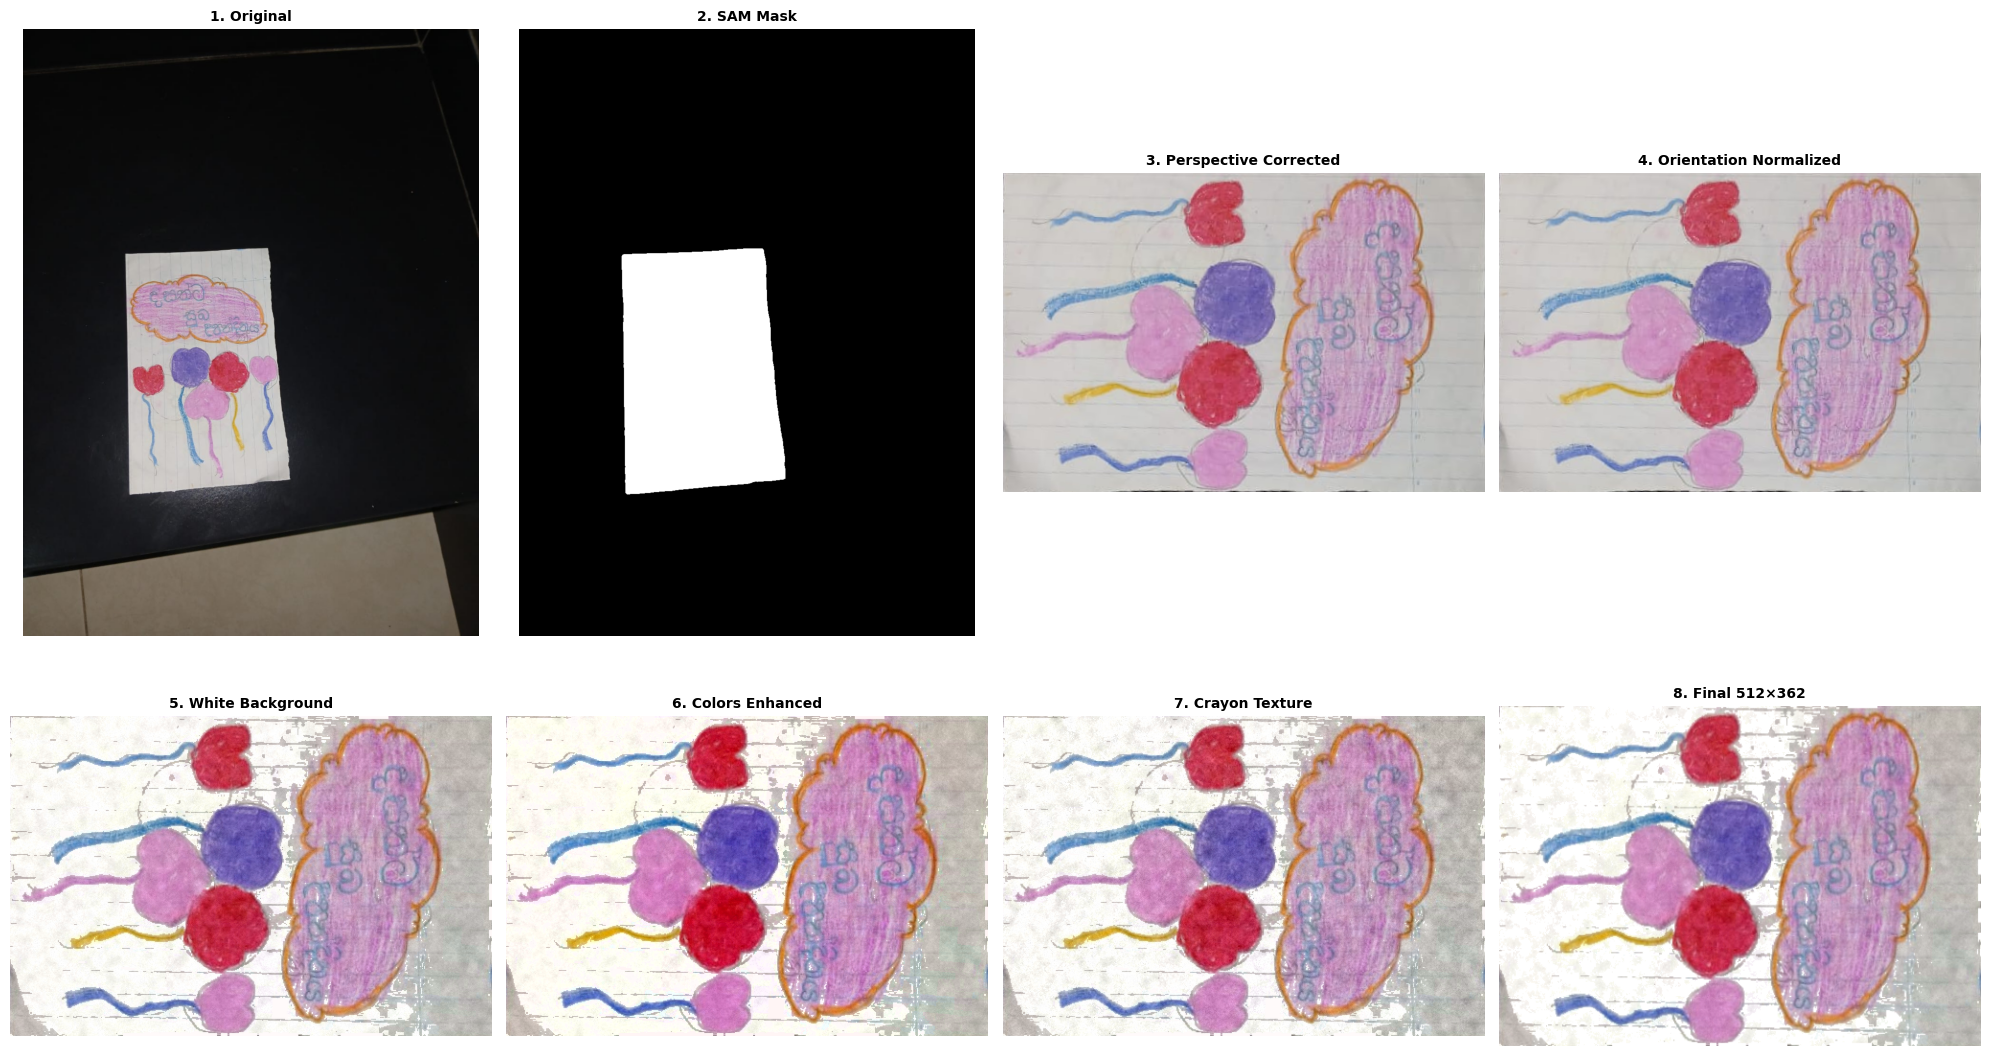

COMPLETE


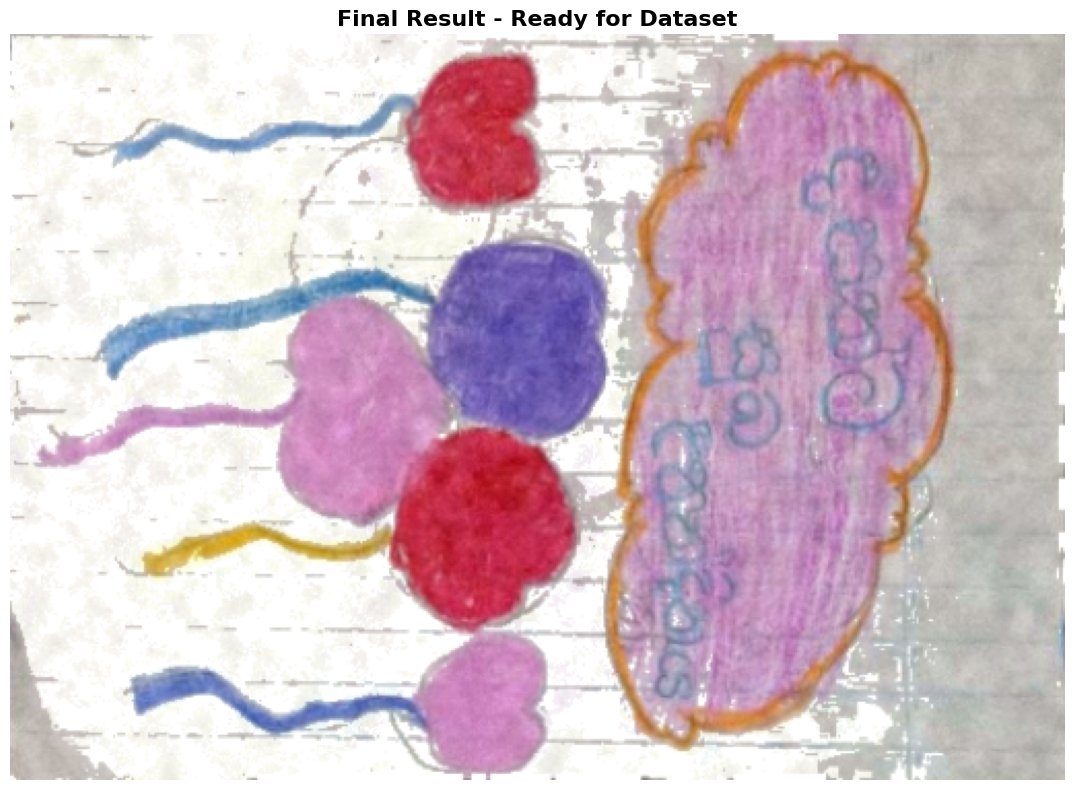


 SUCCESS!


In [15]:
if __name__ == "__main__":

    # Initialize SAM Detector
    print(" Initializing SAM Paper Detector...")
    print("   Using 'vit_b' model (375MB) - optimized for speed")

    detector = SAM_PaperDetector(model_type='vit_b')

    try:
        final_result = full_pipeline_sam(
            image_path="../data/with line.jpeg",
            detector=detector,
            debug=True,                   # Show all processing steps
            save_path="../data/output/output.png",       # Output file
            texture_grain=0.5,            # Crayon grain intensity (0.3-0.7)
            texture_stroke=0.4,           # Stroke visibility (0.3-0.5)
            target_width=512,             # Dataset width
            target_height=362             # Dataset height
        )

        # Display final result
        plt.figure(figsize=(12, 8))
        plt.imshow(final_result)
        plt.title("Final Result - Ready for Dataset", fontsize=16, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()
        plt.show()

        print("\n SUCCESS!")

    except Exception as e:
        print(f"\n ERROR: {e}")
        import traceback
        traceback.print_exc()